# Plotting vertical layers in MOM6

One of the features of MOM6 is the flexible vertical coordinate, where the Vertical Lagrangian Remap method allows you to run your model in arbitrary target vertical coordinates.

Sometimes it is useful to visualise these layers in a transect of the model, for example, for comparison between model runs with different vertical coordinate choices. The easiest way to do this is to use the variable `e`, which is the vertical position of layer interfaces. 

**A note on native vs diagnostic coordinates**: MOM6 allows you to output the model output diagnostics in *native* coordinates as well as *diagnostic* coordinates. For example, you could run the model with a target coordinate of density layers but output all your diagnostics in z/geopotential-level coordinates. Additionally, the native coordinates contain non-masked output in *vanished layers* that exist at the bottom of the ocean. This means if you did a rough plot of *native coordinate output*, you would see data at all target depths and no masked topography. 

For example: this rough plot below is a transect of temperature and the data extends down to the target depth of 6000m everywhere despite no layer existing there in most places as it is vanished on top of the bottom topography. This is because the vertical coordinate of the native coordinate data is *target depth* rather than actual depth.
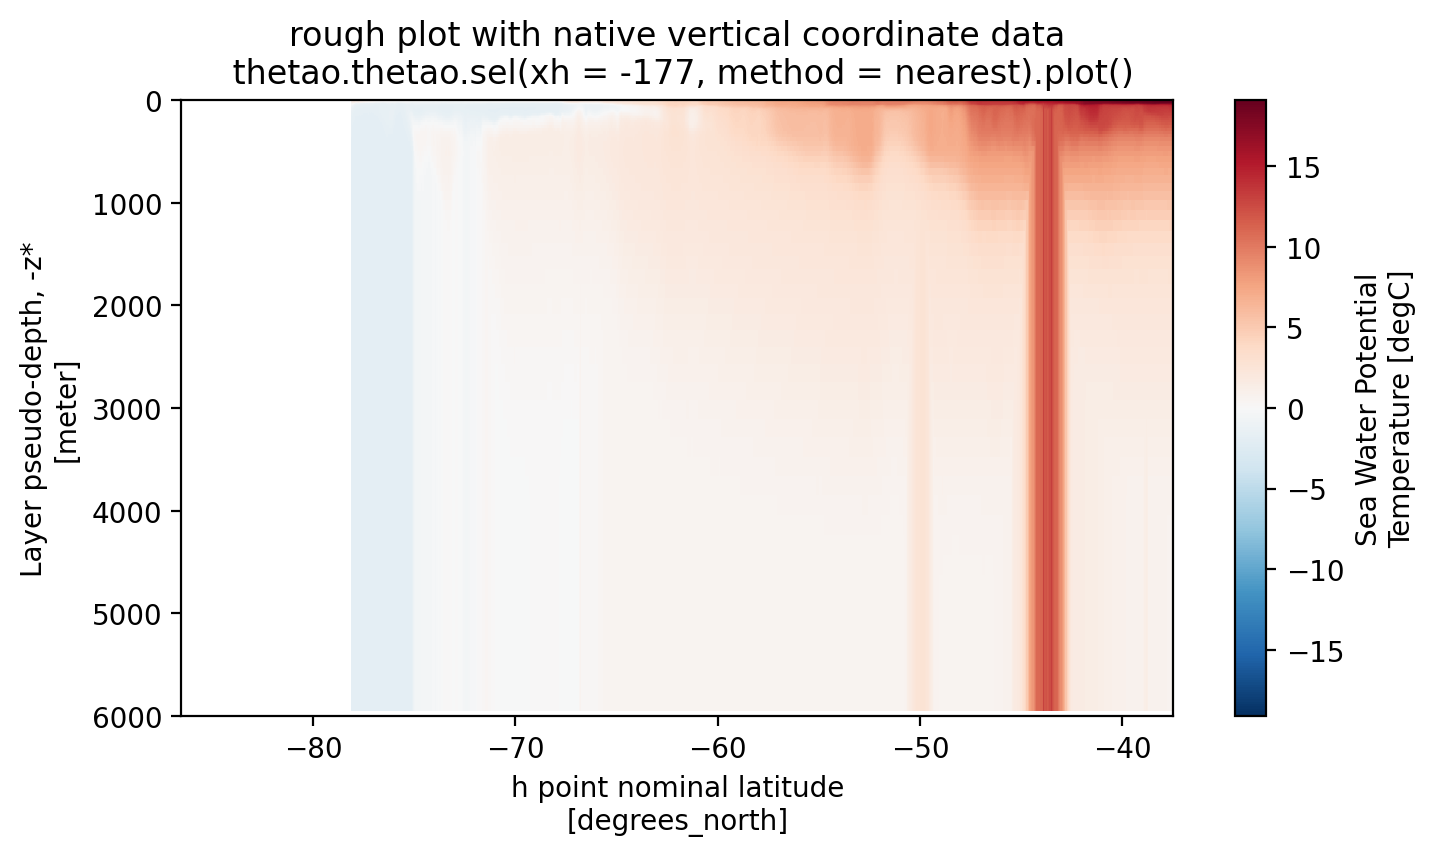

In ACCESS-OM3 our 3D diagnostics usually use regridded diagnostic output to $z$ coordinates, which does mask out the vanished layers and regrids their values to the correct depth. To tell the difference, the file name will often differ (e.g. `access-om3.mom6.3d.thetao+z.1mon.mean.1990.nc` indicates regridded to z. We also regrid some data to density coordinates e.g. `access-om3.mom6.3d.vmo+rho2.1mon.mean.1990.nc` used for overturning streamfunction in density coordinate calculations.

A second way you can tell the difference is that the vertical coordinate in native coordinates has the name `zl` (for layer centre) and `zi` (for layer interfaces) whereas in regridded coordinates it is `z_l` and `z_i`.

We can plot the vertical layers in either case - it is just useful to know whether that is the coordinate the model was run on, or whether it is simply what the diagnostic is being outputted on.

**Plotting native coordinates in MOM6**: Alistair Adcroft has a notebook that explains in detail the pitfalls of plotting cross-sections in MOM6 with native coordinates. One of the issues is that of the vanished layers mentioned above. Another is the fact that plotting with trapezoid shapes (neighbouring columns share edges and corners of grid cell) results in a non-conservative representation of the data (Here, we will ignore this aspect). Alistair's notebook is here: https://gist.github.com/adcroft/dde8d3fafd77d0caaa5613e64f1d7eff

Let's first load useful packages

In [1]:
from dask.distributed import Client
import numpy as np
import xarray as xr
import dask

import xgcm
import intake

# For plotting
import matplotlib.pyplot as plt
import cmocean as cm

In [2]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45895 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45895/status,
Dashboard: /proxy/45895/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34859,Workers: 0
Dashboard: /proxy/45895/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34629,Total threads: 1
Dashboard: /proxy/39245/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:34781,


Let's load some data using intake. We will use an early version of the ACCESS-OM3 pan-Antarctic model with ice shelves which is not in the catalog. The `e` variable is always required when plotting transects through ice shelves as the native and regridded coordinates do not account for the depression of the sea surface by ice shelf pressure.

In [3]:
columns = [
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] 
# not a permanent data location but it's a more interesting vertical coordinate than z*
pathmain = "/g/data/ik11/outputs/access-rom3-panan/MC_4km_jra_iaf+regionalpanan+isf/"
esm_datastore = intake.open_esm_datastore(
    pathmain + "experiment_datastore.json", 
    columns_with_iterables= columns)

# load diagnostic temperature and layer interface variables 
# just for a one month
time_slice = slice('1990-01-01','1990-01-31')

temp = esm_datastore.search(variable="temp",
                            frequency='1mon',
                            start_date='1990-0[1-3].*').to_dask(
                            xarray_open_kwargs={'decode_timedelta' : True,
                                                'chunks' : {'yh':-1}},
                            )

e = esm_datastore.search(variable="e",
                         file_id = 'ocean.1mon.nv:2.xh:4320.yh:1442.z_i:76.z_l:75',
                         start_date='1990-0[1-3].*').to_dask(
                         xarray_open_kwargs={'decode_timedelta' : True,
                                             'chunks' : {'yh':-1}},
                         )

temp = temp.sel(time = time_slice)
e = e.sel(time = time_slice)




Load static grid data and create an xgcm grid for interpolation. If creating a meridional transect, we need to move the `e` variable to `yq` (velocity) points instead of `yh` (tracer) points so that we can use pcolormesh properly (see Alistair's notebook above)

In [4]:
static = esm_datastore.search(variable=["xh","yh","xq","yq"],frequency='fx').to_dask(
        xarray_open_kwargs={'chunks' : {'yh':-1,'yq':-1}},
)

grid = xgcm.Grid(static, 
                 coords = {"x":{"center":"xh","outer":"xq"},
                             "y":{"center":"yh","outer":"yq"}},
                 periodic = "x",
                 autoparse_metadata = False)

Interpolate `e` to `yq` points.

Note `e` could vary in time (for example, as sea level rises and moves floating ice shelf) but for simplicity we will just take a one month average.

In [5]:
layer_interfaces = e.e.isel(time = 0)
e_on_yq = grid.interp(layer_interfaces,"y")

Now plot a transect

In [ ]:
# define longitude target
lon = -177

# define transect
transect = temp.temp.sel(xh = lon, method = 'nearest').isel(time = 0)
# define y positions
yqs,zis = np.meshgrid(e_on_yq.yq,e_on_yq.z_i)
# define depth positions
etas = e_on_yq.sel(xh = lon, method = 'nearest').bfill("yq").bfill("z_i").ffill("yq").ffill("z_i")

# make figure
fig, axes = plt.subplots(figsize = (10,5),dpi = 200)

# use pcolormesh to plot
c = axes.pcolormesh(yqs,etas,transect, cmap = cm.cm.thermal, vmax = 2, vmin = -3)

# plot all the vertical layers
for i in np.arange(len(layer_interfaces.z_i)):
    layer_interfaces.sel(xh = lon, method = 'nearest').isel(z_i = i).plot(
        ax = axes, color = 'k', lw = 0.3)

# make colorbar
plt.colorbar(c, ax = axes, label = 'potential temperature ($^\circ$C)')

# set axes limits and labels
axes.set_ylim(-3000,0)
axes.set_xlabel('Latitude ($^\circ$N)')

axes.set_xlim(-87,-60)
axes.set_ylabel('Depth (m)')

axes.set_title('Transect of temperature through 177$^\circ$W')


It's a bit hard to see the layers in the cavity so let's zoom in more

In [ ]:
# define longitude target
lon = -177

# define transect
transect = temp.temp.sel(xh = lon, method = 'nearest').isel(time = 0)
# define y positions
yqs,zis = np.meshgrid(e_on_yq.yq,e_on_yq.z_i)
# define depth positions, and fill sideways and upwards as it can't contain NaNs
etas = e_on_yq.sel(xh = lon, method = 'nearest').bfill("yq").bfill("z_i").ffill("yq").ffill("z_i")

# make figure
fig, axes = plt.subplots(figsize = (10,5),dpi = 200)

# use pcolormesh to plot
c = axes.pcolormesh(yqs,etas,transect, cmap = cm.cm.thermal, vmax = 2, vmin = -3)

# plot all the vertical layers
for i in np.arange(len(layer_interfaces.z_i)):
    layer_interfaces.sel(xh = lon, method = 'nearest').isel(z_i = i).plot(
        ax = axes, color = 'k', lw = 0.3)

# make colorbar
plt.colorbar(c, ax = axes, label = 'potential temperature ($^\circ$C)')

# set axes limits and labels
axes.set_ylim(-1200,0)
axes.set_xlabel('Latitude ($^\circ$N)')

axes.set_xlim(-85,-74)
axes.set_ylabel('Depth (m)')

axes.set_title('Transect of temperature through 177$^\circ$W')


In [ ]:
client.close()